In [3]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Telecom Dataset.csv")

df.head(15)

,PID,Blue,Wi_Fi,Tch_Scr,Ext_Mem,Px_h,Px_w,Scr_h,Scr_w,PC,FC,Int_Mem,Bty_Pwr,RAM,Depth,Weight,Price
0,AAB346A,yes,yes,no,no,780,460,3,1,2,2,8,2800,2,7,320,3297
1,AAC347I,yes,yes,no,no,780,560,2,1,4,2,8,3000,2,7,280,4500
2,BAB657J,no,yes,no,no,840,720,2,1,4,2,8,3300,2,7,400,4898
3,BBD456K,no,yes,yes,no,1280,1120,5,3,6,2,32,3000,2,3,300,6900
4,CCP761U,no,yes,yes,no,1280,1080,4,3,6,2,16,3000,2,3,210,5600
5,CCQ674K,yes,no,no,no,1280,1080,4,3,6,4,8,2980,2,3,230,4990
6,CTX123L,yes,no,yes,no,1390,1080,6,3,8,4,32,3000,2,3,100,13400
7,DFR256N,yes,no,no,no,2880,2120,8,6,12,8,32,3200,2,3,80,15600
8,DGS789M,yes,yes,yes,yes,2580,1920,6,3,32,16,8,2800,6,3,120,27688
9,ENG897N,yes,yes,yes,yes,2580,1980,5,3,64,32,64,4380,4,3,150,23456


In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 17 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   PID      50 non-null     str  
 1   Blue     50 non-null     str  
 2   Wi_Fi    50 non-null     str  
 3   Tch_Scr  50 non-null     str  
 4   Ext_Mem  50 non-null     str  
 5   Px_h     50 non-null     int64
 6   Px_w     50 non-null     int64
 7   Scr_h    50 non-null     int64
 8   Scr_w    50 non-null     int64
 9   PC       50 non-null     int64
 10  FC       50 non-null     int64
 11  Int_Mem  50 non-null     int64
 12  Bty_Pwr  50 non-null     int64
 13  RAM      50 non-null     int64
 14  Depth    50 non-null     int64
 15  Weight   50 non-null     int64
 16  Price    50 non-null     int64
dtypes: int64(12), str(5)
memory usage: 6.8 KB


,Px_h,Px_w,Scr_h,Scr_w,PC,FC,Int_Mem,Bty_Pwr,RAM,Depth,Weight,Price
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,2319.400000,1833.200000,6.500000,4.620000,42.160000,20.760000,173.760000,3740.000000,5.760000,3.440000,195.200000,33794.860000
std,598.400623,469.713069,2.042907,1.883223,30.174567,14.784934,261.771871,958.817299,2.759473,1.052887,75.761171,25037.535393
min,780.000000,460.000000,2.000000,1.000000,2.000000,2.000000,8.000000,2300.000000,2.000000,2.000000,80.000000,3297.000000
25%,2080.000000,1775.000000,5.000000,3.000000,12.000000,8.000000,32.000000,2800.000000,4.000000,3.000000,142.500000,19126.500000
50%,2580.000000,1980.000000,6.000000,5.000000,40.000000,16.000000,64.000000,3300.000000,5.000000,3.000000,190.000000,29349.500000
75%,2580.000000,2120.000000,8.000000,6.000000,64.000000,32.000000,128.000000,4500.000000,8.000000,4.000000,247.500000,43560.000000
max,2880.000000,2520.000000,10.000000,8.000000,128.000000,64.000000,1024.000000,5600.000000,12.000000,7.000000,400.000000,149000.000000


Check the actual values in the categorical columns


In [6]:
categorical_cols = {"Blue", "Wi_Fi", "Tch_Scr", "Ext_Mem"}

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

Ext_Mem: <StringArray>
['no', 'yes']
Length: 2, dtype: str
Wi_Fi: <StringArray>
['yes', 'no']
Length: 2, dtype: str
Tch_Scr: <StringArray>
['no', 'yes']
Length: 2, dtype: str
Blue: <StringArray>
['yes', 'no']
Length: 2, dtype: str


In [7]:
binary_cols = ["Blue", "Wi_Fi", "Tch_Scr", "Ext_Mem"]

for col in binary_cols:
    df[col] = df[col].map({
        "yes": 1,
        "no": 0
    })

df.head(5)

,PID,Blue,Wi_Fi,Tch_Scr,Ext_Mem,Px_h,Px_w,Scr_h,Scr_w,PC,FC,Int_Mem,Bty_Pwr,RAM,Depth,Weight,Price
0,AAB346A,1,1,0,0,780,460,3,1,2,2,8,2800,2,7,320,3297
1,AAC347I,1,1,0,0,780,560,2,1,4,2,8,3000,2,7,280,4500
2,BAB657J,0,1,0,0,840,720,2,1,4,2,8,3300,2,7,400,4898
3,BBD456K,0,1,1,0,1280,1120,5,3,6,2,32,3000,2,3,300,6900
4,CCP761U,0,1,1,0,1280,1080,4,3,6,2,16,3000,2,3,210,5600


In [11]:
if "PID" in df.columns:
    df.drop("PID", axis=1, inplace=True)
else:
    print("PID column not found in the DataFrame.", df.columns)

PID column not found in the DataFrame. Index(['Blue', 'Wi_Fi', 'Tch_Scr', 'Ext_Mem', 'Px_h', 'Px_w', 'Scr_h', 'Scr_w',
       'PC', 'FC', 'Int_Mem', 'Bty_Pwr', 'RAM', 'Depth', 'Weight', 'Price'],
      dtype='str')


In [16]:
df.describe(include = [np.number])

,Blue,Wi_Fi,Tch_Scr,Ext_Mem,Px_h,Px_w,Scr_h,Scr_w,PC,FC,Int_Mem,Bty_Pwr,RAM,Depth,Weight,Price
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,0.540000,0.840000,0.900000,0.760000,2319.400000,1833.200000,6.500000,4.620000,42.160000,20.760000,173.760000,3740.000000,5.760000,3.440000,195.200000,33794.860000
std,0.503457,0.370328,0.303046,0.431419,598.400623,469.713069,2.042907,1.883223,30.174567,14.784934,261.771871,958.817299,2.759473,1.052887,75.761171,25037.535393
min,0.000000,0.000000,0.000000,0.000000,780.000000,460.000000,2.000000,1.000000,2.000000,2.000000,8.000000,2300.000000,2.000000,2.000000,80.000000,3297.000000
25%,0.000000,1.000000,1.000000,1.000000,2080.000000,1775.000000,5.000000,3.000000,12.000000,8.000000,32.000000,2800.000000,4.000000,3.000000,142.500000,19126.500000
50%,1.000000,1.000000,1.000000,1.000000,2580.000000,1980.000000,6.000000,5.000000,40.000000,16.000000,64.000000,3300.000000,5.000000,3.000000,190.000000,29349.500000
75%,1.000000,1.000000,1.000000,1.000000,2580.000000,2120.000000,8.000000,6.000000,64.000000,32.000000,128.000000,4500.000000,8.000000,4.000000,247.500000,43560.000000
max,1.000000,1.000000,1.000000,1.000000,2880.000000,2520.000000,10.000000,8.000000,128.000000,64.000000,1024.000000,5600.000000,12.000000,7.000000,400.000000,149000.000000


### EDA start

In [17]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

             Blue     Wi_Fi   Tch_Scr   Ext_Mem      Px_h      Px_w     Scr_h  \
Blue     1.000000  0.144487 -0.173891 -0.142819  0.133192  0.110774  0.009921   
Wi_Fi    0.144487  1.000000  0.218218  0.137956  0.064944  0.075744 -0.107902   
Tch_Scr -0.173891  0.218218  1.000000  0.593171  0.566860  0.605888  0.445021   
Ext_Mem -0.142819  0.137956  0.593171  1.000000  0.458723  0.412749  0.324178   
Px_h     0.133192  0.064944  0.566860  0.458723  1.000000  0.962988  0.619936   
Px_w     0.110774  0.075744  0.605888  0.412749  0.962988  1.000000  0.651433   
Scr_h    0.009921 -0.107902  0.445021  0.324178  0.619936  0.651433  1.000000   
Scr_w   -0.058978 -0.118222  0.396933  0.287362  0.582562  0.629169  0.962787   
PC       0.340790  0.342033  0.407972  0.166051  0.634229  0.697908  0.420454   
FC       0.338547  0.291030  0.390808  0.150761  0.619173  0.680534  0.395268   
Int_Mem  0.301727  0.194959  0.207043 -0.030880  0.328951  0.416436  0.400244   
Bty_Pwr  0.250280  0.226453 

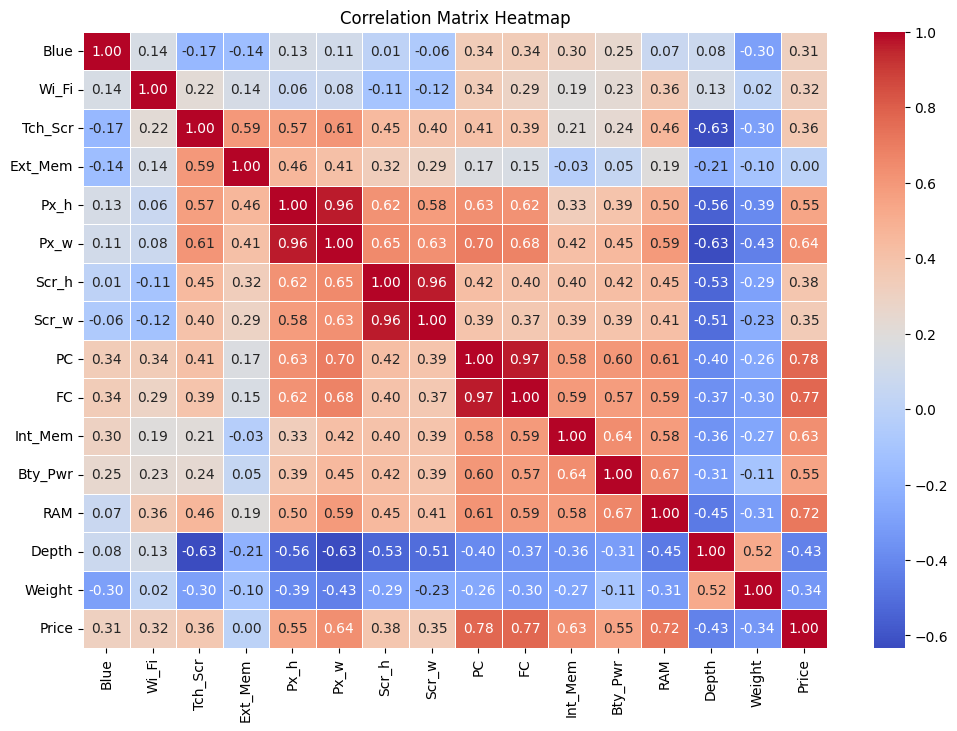

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()


In [19]:
price_corr = (
    corr_matrix["Price"]
    .sort_values(ascending=False)
)

print(price_corr)

Price      1.000000
PC         0.775305
FC         0.773323
RAM        0.715880
Px_w       0.635222
Int_Mem    0.631335
Bty_Pwr    0.549662
Px_h       0.546202
Scr_h      0.376118
Tch_Scr    0.364964
Scr_w      0.345074
Wi_Fi      0.318530
Blue       0.305292
Ext_Mem    0.000356
Weight    -0.335719
Depth     -0.425357
Name: Price, dtype: float64


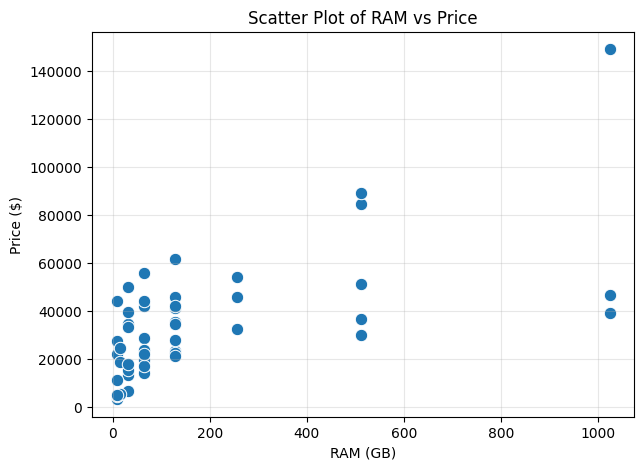

In [26]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Int_Mem",
    y="Price",
    s=80
)
plt.title("Scatter Plot of RAM vs Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price ($)")
plt.grid(alpha=0.3)
plt.show()

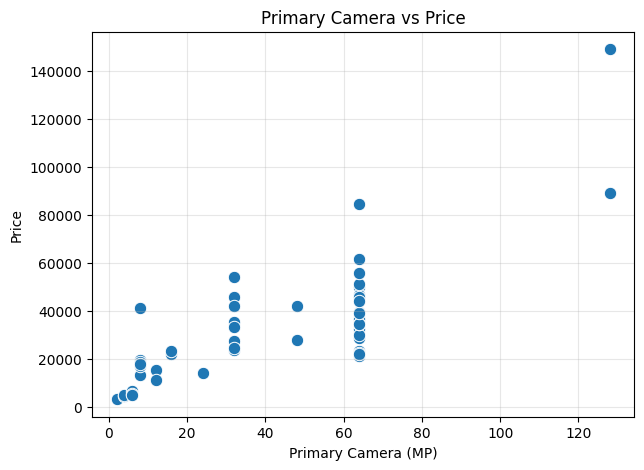

In [24]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="PC",
    y="Price",
    s=80
)

plt.title("Primary Camera vs Price")
plt.xlabel("Primary Camera (MP)")
plt.ylabel("Price")
plt.grid(alpha=0.3)

plt.show()

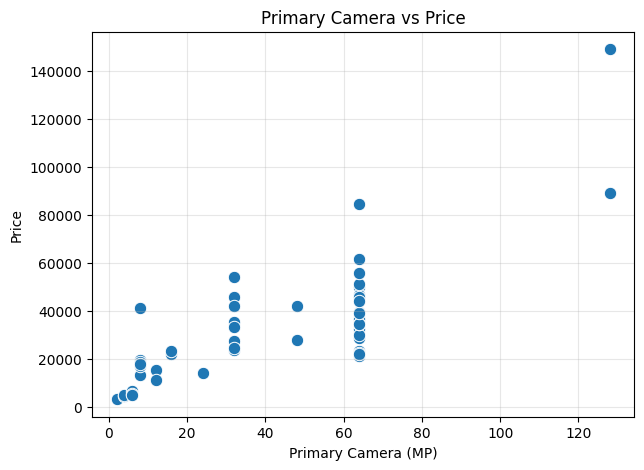

In [27]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="PC",
    y="Price",
    s=80
)

plt.title("Primary Camera vs Price")
plt.xlabel("Primary Camera (MP)")
plt.ylabel("Price")
plt.grid(alpha=0.3)

plt.show()

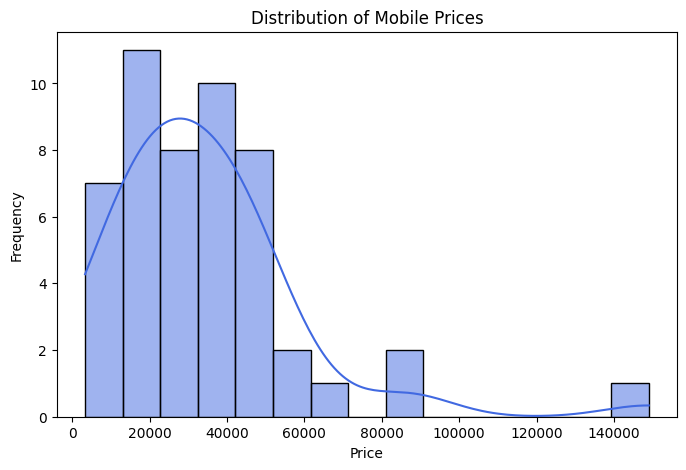

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(df["Price"], bins=15, kde=True, color="royalblue")

plt.title("Distribution of Mobile Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11628\932243084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


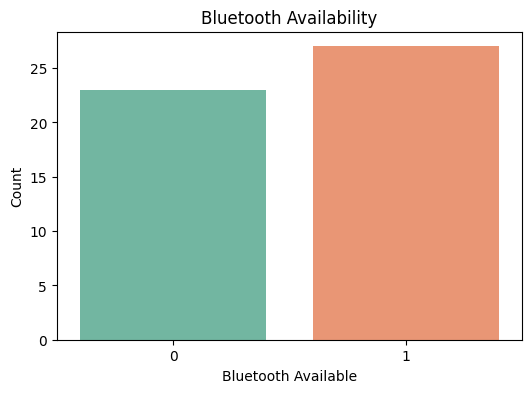

In [29]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Blue",
    palette="Set2"
)

plt.title("Bluetooth Availability")
plt.xlabel("Bluetooth Available")
plt.ylabel("Count")
plt.show()

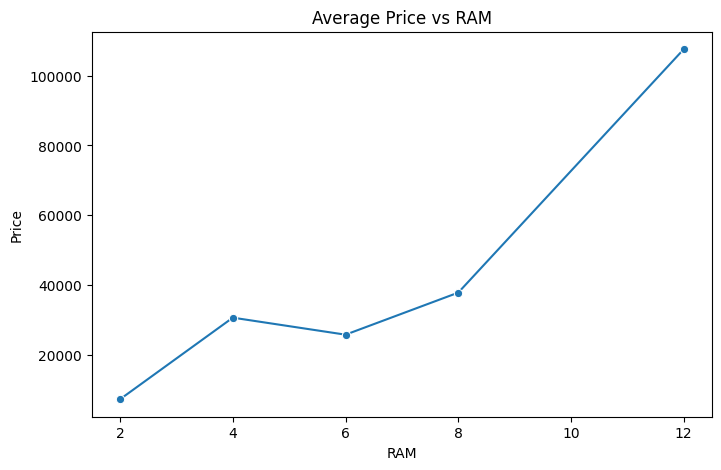

In [30]:
price_by_ram = df.groupby("RAM")["Price"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(
    data=price_by_ram,
    x="RAM",
    y="Price",
    marker="o"
)

plt.title("Average Price vs RAM")

plt.show()

### Feature engineering

In [31]:
df["Total_Pixels"] = df["Px_h"] * df["Px_w"]

In [32]:
df["Pixel_Density"] = np.sqrt(df["Px_h"]**2 + df["Px_w"]**2) / np.sqrt(df["Scr_h"]**2 + df["Scr_w"]**2)

df["screen_area"] = df["Scr_h"] * df["Scr_w"]



In [41]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [34]:
X = df.drop(["Price"], axis=1)
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
baseline_prediction = np.full(
    shape=len(y_test),
    fill_value=y_train.mean()
)

In [36]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_prediction
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 14479.1


In [37]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [38]:
lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

print("Linear Regression MAE:", lr_mae)

Linear Regression MAE: 19566.488707885146


In [39]:
print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Linear Regression MAE: {lr_mae:.2f}")

Baseline MAE: 14479.10
Linear Regression MAE: 19566.49


Since:
    1350 < 6150

✅ Linear Regression is much better than the baseline.

In [40]:
print("R² Score:", r2_score(y_test, lr_pred))

R² Score: -0.30460489878980623


In [44]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [45]:
models = {
    "Linear Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
    "Ridge Regression":
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=1.0))
        ]),
    "Lasso Regression": Pipeline([
                ("scaler", StandardScaler()),
                ("model", Lasso(alpha=0.1))
            ]),
    "Random Forest": RandomForestRegressor( n_estimators=100, random_state=42)
}



In [46]:
results = []

for name, model in models.items():
    scores = cross_validate(model,X,y,cv=cv,
        scoring={
            "MAE":"neg_mean_absolute_error",
            "RMSE":"neg_root_mean_squared_error",
            "R2":"r2"}
    )

    results.append({
        "Model":name,
        "Mean MAE":-scores["test_MAE"].mean(),
        "Mean RMSE":-scores["test_RMSE"].mean(),
        "Mean R²":scores["test_R2"].mean()
    })

cv_results = pd.DataFrame(results)

cv_results = cv_results.sort_values(
    "Mean MAE"
)

print(cv_results)

d:\program\min data set project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.667e+09, tolerance: 2.649e+06
  model = cd_fast.enet_coordinate_descent(
d:\program\min data set project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.860e+09, tolerance: 2.542e+06
  model = cd_fast.enet_coordinate_descent(
d:\program\min data set project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis

               Model      Mean MAE     Mean RMSE   Mean R²
3      Random Forest   9550.743800  13997.750229  0.614455
1   Ridge Regression  11046.934645  15233.179242  0.500314
2   Lasso Regression  12664.286947  17129.370829  0.372889
0  Linear Regression  12880.310431  17361.494761  0.351958


In [47]:
best_model_name = cv_results.iloc[0]["Model"]

print(f"\nBest Model : {best_model_name}")


Best Model : Random Forest


In [48]:
bestModel = models[best_model_name]

bestModel.fit(X_train, y_train)

pred = bestModel.predict(X_test)


In [50]:
mae = mean_absolute_error(y_test,pred)

rmse = np.sqrt(mean_squared_error(y_test,pred))

r2 = r2_score(y_test, pred)

print("Test Performance ")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

Test Performance 
MAE : 13427.88
RMSE: 16536.84
R²  : 0.3392


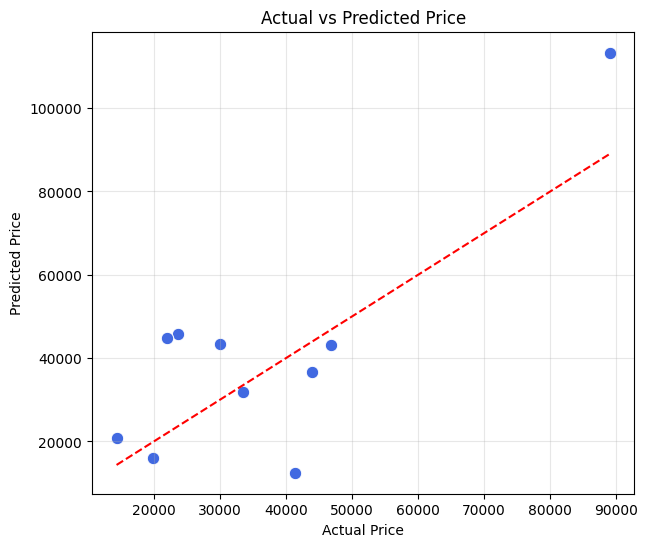

In [51]:
plt.figure(figsize=(7,6))
sns.scatterplot(x=y_test, y=pred, s=80, color="royalblue")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.grid(alpha=0.3)
plt.show()

In [53]:
import joblib

# Refit the champion on ALL rows (not just X_train).
# Once you've chosen + evaluated a model, you retrain on every row you have
# so the saved model is as informed as possible.
final_model = models[best_model_name]
final_model.fit(X, y)

# Save the model AND the exact feature column order together.
# Column order matters: sklearn matches by position, so we store it to be safe.
artifact = {
    "model": final_model,
    "feature_names": list(X.columns),
    "model_name": best_model_name,
}
joblib.dump(artifact, "mobile_price_model.joblib")

print(f"Saved '{best_model_name}' to mobile_price_model.joblib")
print("Features it expects:", list(X.columns))

Saved 'Random Forest' to mobile_price_model.joblib
Features it expects: ['Blue', 'Wi_Fi', 'Tch_Scr', 'Ext_Mem', 'Px_h', 'Px_w', 'Scr_h', 'Scr_w', 'PC', 'FC', 'Int_Mem', 'Bty_Pwr', 'RAM', 'Depth', 'Weight', 'Total_Pixels', 'Pixel_Density', 'screen_area']


In [54]:
def predict_price(raw_specs, artifact_path="mobile_price_model.joblib"):
    """
    raw_specs: dict of the ORIGINAL specs (no PID, no Price, no engineered cols).
    Returns the predicted price.
    """
    art = joblib.load(artifact_path)
    model = art["model"]
    feature_names = art["feature_names"]

    row = dict(raw_specs)  # copy so we don't mutate the caller's dict

    # 1) Convert yes/no flags to 1/0 (same mapping you used in cleaning)
    for col in ["Blue", "Wi_Fi", "Tch_Scr", "Ext_Mem"]:
        if isinstance(row.get(col), str):
            row[col] = {"yes": 1, "no": 0}[row[col].lower()]

    # 2) Recreate the engineered features EXACTLY as in your notebook
    row["Total_Pixels"]  = row["Px_h"] * row["Px_w"]
    row["Pixel_Density"] = (np.sqrt(row["Px_h"]**2 + row["Px_w"]**2)
                            / np.sqrt(row["Scr_h"]**2 + row["Scr_w"]**2))
    row["screen_area"]   = row["Scr_h"] * row["Scr_w"]

    # 3) Put columns in the exact order the model was trained on
    X_new = pd.DataFrame([row])[feature_names]

    return float(model.predict(X_new)[0])


# --- try it on a made-up phone ---
example_phone = {
    "Blue": "yes", "Wi_Fi": "yes", "Tch_Scr": "yes", "Ext_Mem": "yes",
    "Px_h": 1920, "Px_w": 1080, "Scr_h": 15, "Scr_w": 8,
    "PC": 13, "FC": 8, "Int_Mem": 64, "Bty_Pwr": 4000,
    "RAM": 6, "Depth": 8, "Weight": 180,
}
print(f"Predicted price: {predict_price(example_phone):,.0f}")

Predicted price: 19,763


## Summary: Predicting Mobile Phone Price from Specs

**Goal:** Predict a phone's `Price` from its hardware specs (regression).

**Data:** 50 phones, 16 spec features. Cleaned yes/no flags to 0/1,
dropped the `PID` identifier, engineered Total_Pixels, Pixel_Density,
and screen_area.

**Approach:** Compared a mean baseline, Linear/Ridge/Lasso, and Random
Forest using 5-fold cross-validation (chosen over a single split because
50 rows makes one test set noisy).

**Result:** Random Forest was the CV champion (CV MAE ≈ 9,550, R² ≈ 0.61).
On the held-out test set it scored MAE ≈ 13,400 — the gap reflects how
sensitive a ~10-row test set is on a small dataset.

**Top price drivers:** [fill from your correlation / feature importances,
e.g. RAM, Int_Mem, battery].

**Limitations & next steps:** Only 50 rows, so results are indicative,
not reliable — more data is the single biggest improvement available.
Would also tune Random Forest depth and try log-transforming Price.